In [2]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
raw_data = pd.read_csv('./data/cleaned_gun_violence_data.csv')

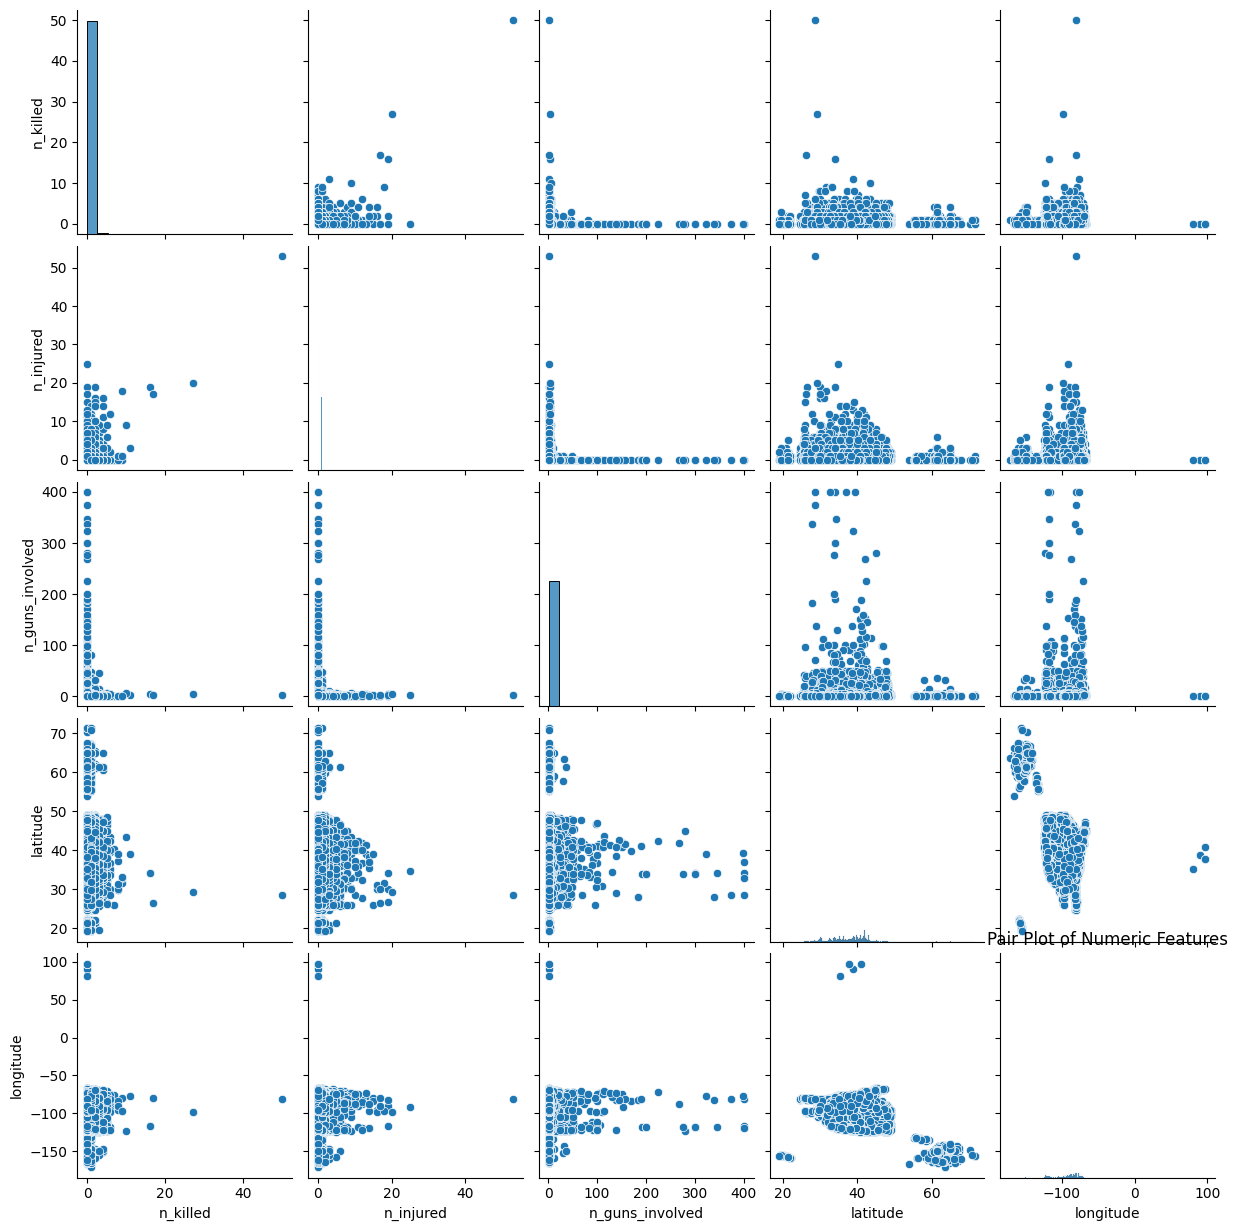

In [ ]:
sns.pairplot(raw_data[['n_killed', 'n_injured', 'n_guns_involved', 'latitude', 'longitude']])
plt.title('Pair Plot of Numeric Features')
plt.show()

In [ ]:
raw_data['gun_stolen_TF'].value_counts()

,count
gun_stolen_TF,
False,232327
True,7350


In [ ]:
raw_data.columns

Index(['incident_id', 'date', 'state', 'city_or_county', 'address', 'n_killed',
       'n_injured', 'incident_url', 'source_url',
       'incident_url_fields_missing', 'congressional_district', 'gun_stolen',
       'gun_type', 'incident_characteristics', 'latitude',
       'location_description', 'longitude', 'n_guns_involved', 'notes',
       'participant_age', 'participant_age_group', 'participant_gender',
       'participant_name', 'participant_relationship', 'participant_status',
       'participant_type', 'sources', 'state_house_district',
       'state_senate_district', 'gun_stolen_TF'],
      dtype='object')

**Stolen Guns are responsible for 300+ Lives and 500+ Injured**

In [ ]:
raw_data.groupby('gun_stolen_TF')['n_killed'].sum()

,n_killed
gun_stolen_TF,
False,60163
True,305


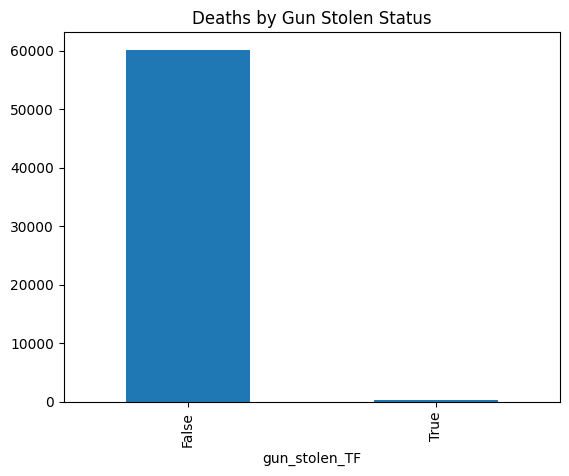

In [ ]:
raw_data.groupby('gun_stolen_TF')['n_killed'].sum().plot(kind='bar')
plt.title('Deaths by Gun Stolen Status')
plt.show()

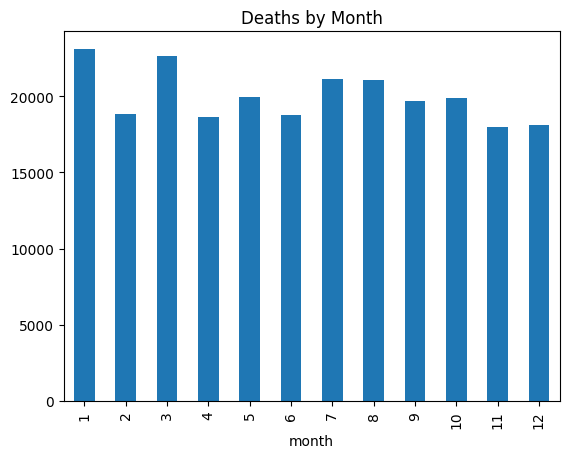

In [ ]:
#no particular month has high rate of shootings

raw_data['date'] = pd.to_datetime(raw_data['date'])
raw_data['month'] = raw_data['date'].dt.month
raw_data['month'].value_counts().sort_index().plot(kind='bar')
plt.title('Deaths by Month')
plt.show()

In [ ]:
import folium
from folium.plugins import HeatMap

heatmap_data = raw_data[['latitude', 'longitude']].dropna()

map_center = [heatmap_data['latitude'].mean(), heatmap_data['longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=4)

HeatMap(data=heatmap_data.values.tolist(), radius=6, blur=7).add_to(m)

m